In [1]:
import torch
from torch import nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

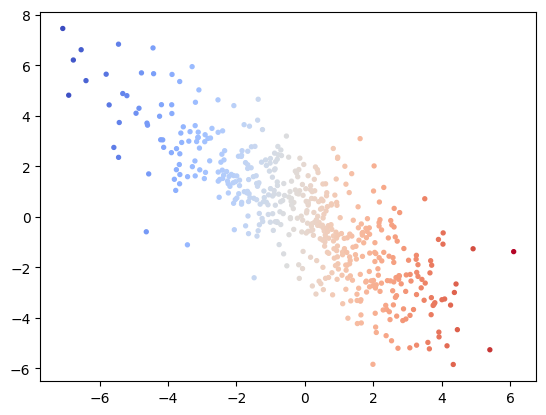

In [158]:
from sklearn.datasets import make_regression

# X, y = make_regression(
#     n_samples=500,
#     n_features=2, 
#     n_targets=1,
#     n_informative=2,
#     tail_strength=0.9,
#     effective_rank=2,
#     noise=0.1,
#     random_state=42
# )

X = np.random.multivariate_normal([0, 0], [[10, 0], [0, 1]], size=(500,))

R = lambda theta: np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)],
])

y = X.sum(1)

X = X @ R(np.pi/4)

plt.scatter(X[:, 0], X[:, 1], c=y, s=8, cmap='coolwarm')

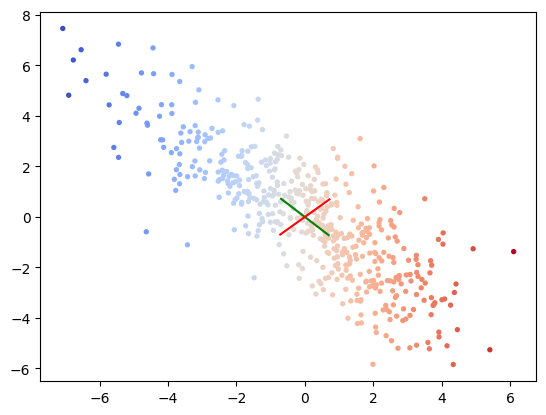

In [159]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2).fit(X)

w1 = pca.components_[0]
w2 = pca.components_[1]

plt.scatter(X[:, 0], X[:, 1], c=y, s=8, cmap='coolwarm')
plt.plot([-w1[0], w1[0]], [-w1[1], w1[1]], color='green')
plt.plot([-w2[0], w2[0]], [-w2[1], w2[1]], color='red')

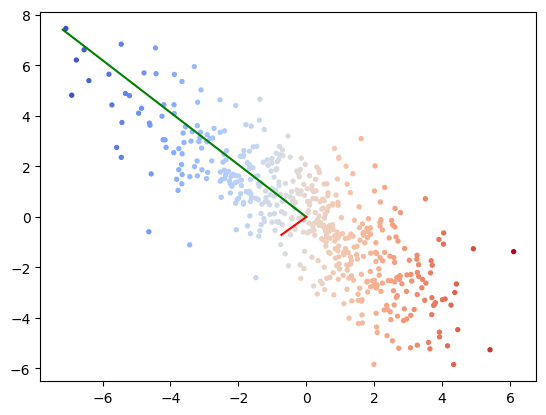

In [160]:
l1, l2 = pca.explained_variance_

plt.scatter(X[:, 0], X[:, 1], c=y, s=8, cmap='coolwarm')
plt.plot([0, l1*w1[0]], [0, l1*w1[1]], color='green')
plt.plot([0, l2*w2[0]], [0, l2*w2[1]], color='red')

In [161]:
D = np.linalg.norm(X[..., None] - X.T, axis=1)

D

array([[0.        , 1.78467445, 2.08894548, ..., 3.18827804, 0.78630573,
        1.7775595 ],
       [1.78467445, 0.        , 1.43880221, ..., 1.97858218, 1.96660182,
        1.12431307],
       [2.08894548, 1.43880221, 0.        , ..., 3.38605584, 1.67613572,
        0.36947863],
       ...,
       [3.18827804, 1.97858218, 3.38605584, ..., 0.        , 3.69877039,
        3.09757431],
       [0.78630573, 1.96660182, 1.67613572, ..., 3.69877039, 0.        ,
        1.46808367],
       [1.7775595 , 1.12431307, 0.36947863, ..., 3.09757431, 1.46808367,
        0.        ]])

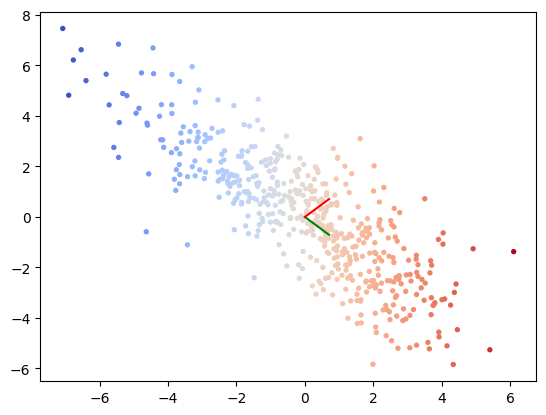

In [162]:
D = np.linalg.norm(X.T[..., None] - X, axis=1)

(l1, l2), (w1, w2) = np.linalg.eig(D)

plt.scatter(X[:, 0], X[:, 1], c=y, s=8, cmap='coolwarm')
plt.plot([0, w1[0]], [0, w1[1]], color='green')
plt.plot([0, w2[0]], [0, w2[1]], color='red')

In [163]:
l1, l2

(101.45395934159535, -101.45395934159532)

In [164]:
w

array([-0.99960544, -0.02808847])

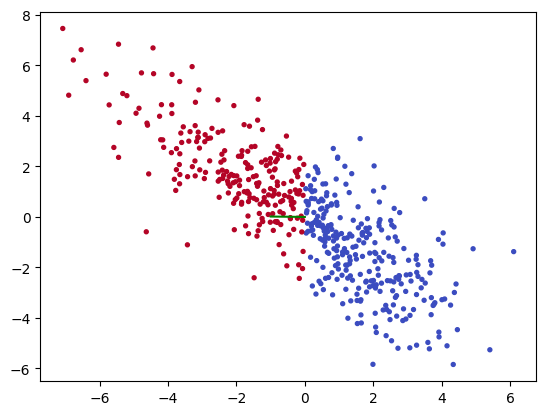

In [165]:
from sklearn.svm import SVC

svm = SVC(kernel='linear').fit(X, y < 0)

plt.scatter(X[:, 0], X[:, 1], c=y<0, s=8, cmap='coolwarm')

w = (svm.coef_ / np.linalg.norm(svm.coef_)).ravel()

plt.plot([0, w[0]], [0, w[1]], color='green')

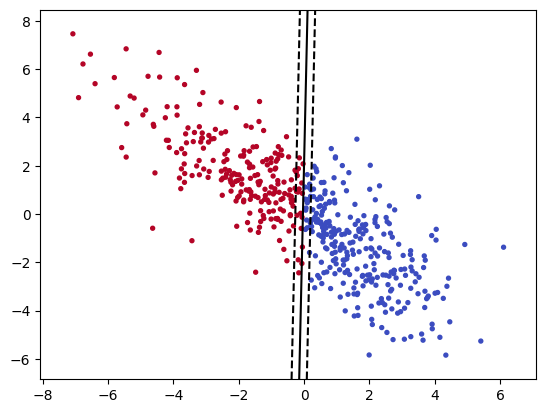

In [166]:
from sklearn.inspection import DecisionBoundaryDisplay

common_params = {"estimator": svm, "X": X}

DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="decision_function",
        plot_method="contour",
        levels=[-1, 0, 1],
        colors=["k", "k", "k"],
        linestyles=["--", "-", "--"],
    )

plt.scatter(X[:, 0], X[:, 1], c=y<0, s=8, cmap='coolwarm')

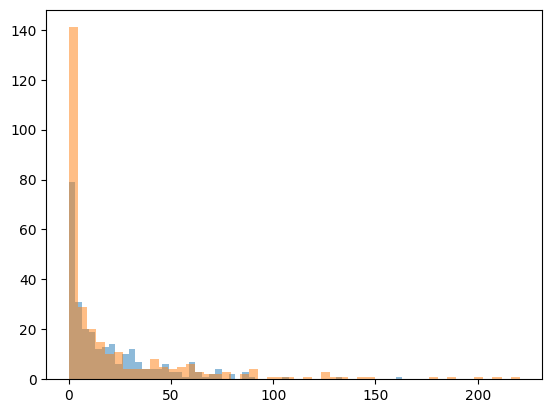

In [167]:
d = abs(X @ svm.coef_.T + svm.intercept_)**2 / np.linalg.norm(svm.coef_, ord=2)

plt.hist(d[y > 0], bins=50, alpha=.5)
plt.hist(d[y <= 1], bins=50, alpha=.5)
plt.show()

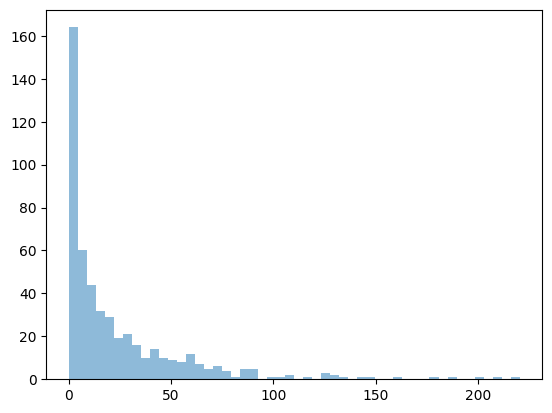

In [168]:
plt.hist(d, bins=50, alpha=.5)
plt.show()

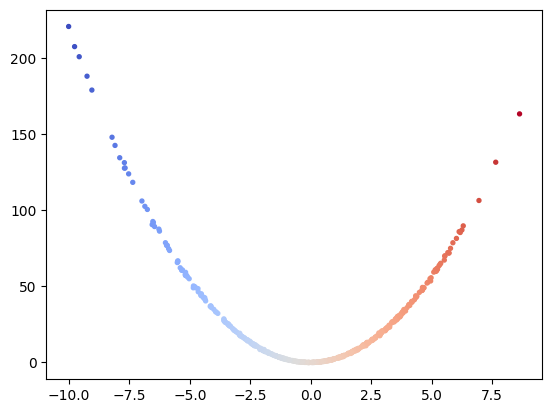

In [169]:
plt.scatter(y, d, s=8, c=y, cmap='coolwarm')

In [ ]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression().fit(d, y)

linreg.coef_, linreg.intercept_

(array([-0.00200147]), -0.09529172182058289)

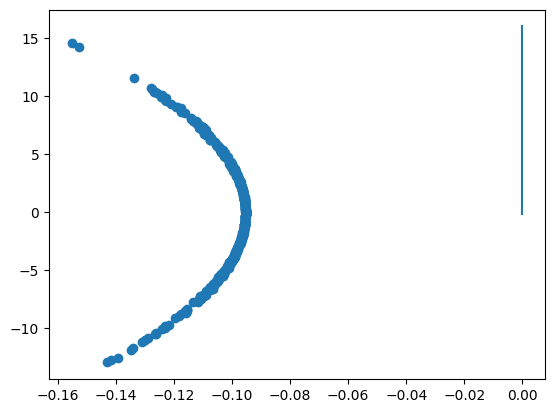

In [ ]:
plt.scatter(linreg.predict(d), y)
plt.plot([-0., -0.2], [0, 16])

## CLIP test

In [1]:
import torch
import clip
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load('RN101', device=device)

In [113]:
import os

base_face_path = r'C:\Users\janba\Downloads\face'

images = []
slider_labels = []
cont_labels = []

scales = np.linspace(-2, 2, 10)

for j, slider_id in enumerate(os.listdir(base_face_path)):

    slider_path = os.path.join(base_face_path, slider_id)
    file_names = os.listdir(slider_path)

    images.extend([Image.open(os.path.join(slider_path, f)) for f in file_names])
    cont_labels.extend([scales[int(f[-5])] for f in file_names])
    slider_labels.extend([j for _ in file_names])

In [114]:
batch = torch.stack([preprocess(im) for im in images]).to(device)

batch.shape

torch.Size([4990, 3, 224, 224])

In [115]:
torch.cuda.empty_cache()

In [116]:
from torch.utils.data import DataLoader

loader = DataLoader(batch, batch_size=32, shuffle=False)

len(loader)

156

In [117]:
batch_features = []

with torch.no_grad():
    for mini_batch in loader:

        batch_features.append(model.encode_image(mini_batch).cpu())
        torch.cuda.empty_cache()

In [118]:
features = torch.concatenate([torch.vstack(batch_features[:-1]), batch_features[-1]], dim=0)

features.shape

torch.Size([4990, 512])

In [119]:
torch_slider_labels = torch.tensor(slider_labels)
torch_cont_labels = torch.tensor(cont_labels)

In [120]:
# age_emb = model.encode_text(clip.tokenize('age').to(device))

# age_emb.shape

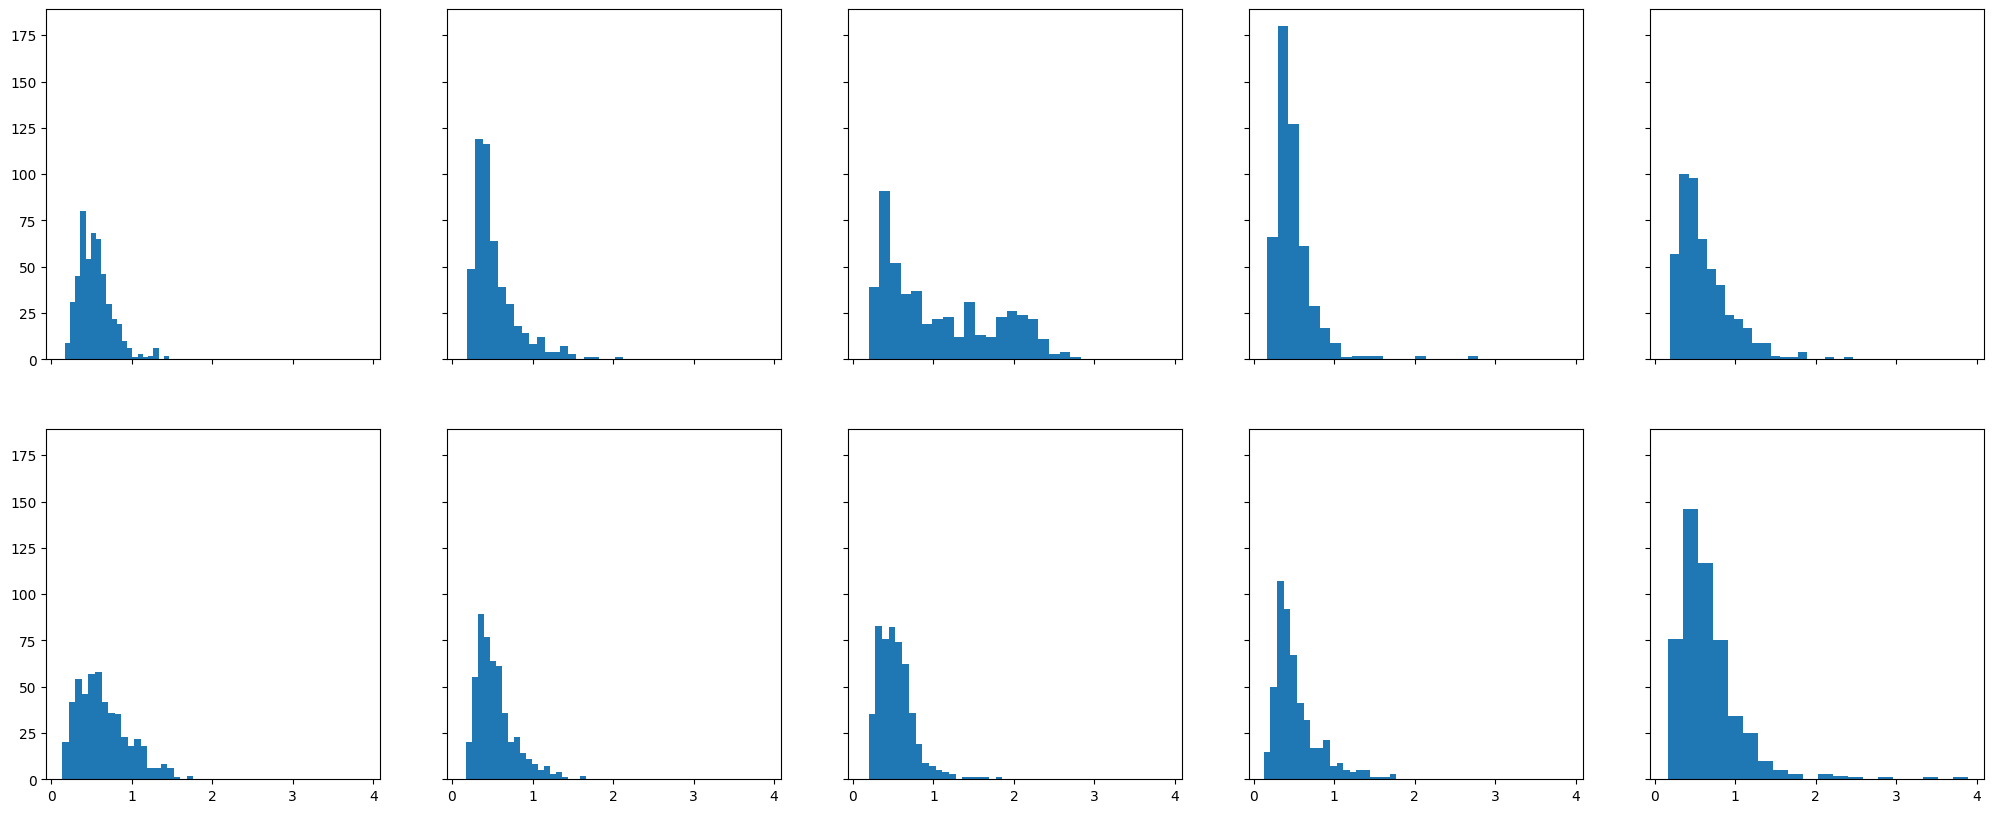

In [125]:
from sklearn.linear_model import LinearRegression

fig, axes = plt.subplots(2, 5, figsize=(25, 10), sharex=True, sharey=True)
axes = axes.flatten()


for slider_idx in range(10):

    D_pos = features[torch_slider_labels == slider_idx]
    D_neg = features[torch_slider_labels != slider_idx]

    y_cont_labels = torch_cont_labels[torch_slider_labels == slider_idx]

    D_pos_mean = D_pos.mean(dim=0)
    D_neg_mean = D_neg.mean(dim=0)

    cav = D_pos_mean - D_neg_mean

    distances = torch.sum((D_pos - D_neg_mean)**2, dim=1)

    # reg = LinearRegression().fit(distances.reshape(-1, 1), y_cont_labels)

    # axes[slider_idx].scatter(distances, y_cont_labels, s=8)
    axes[slider_idx].hist(distances, bins=20)

    # axes[slider_idx].plot([0, 4], [reg.intercept_, reg.coef_[0]*distances.max() + reg.intercept_])

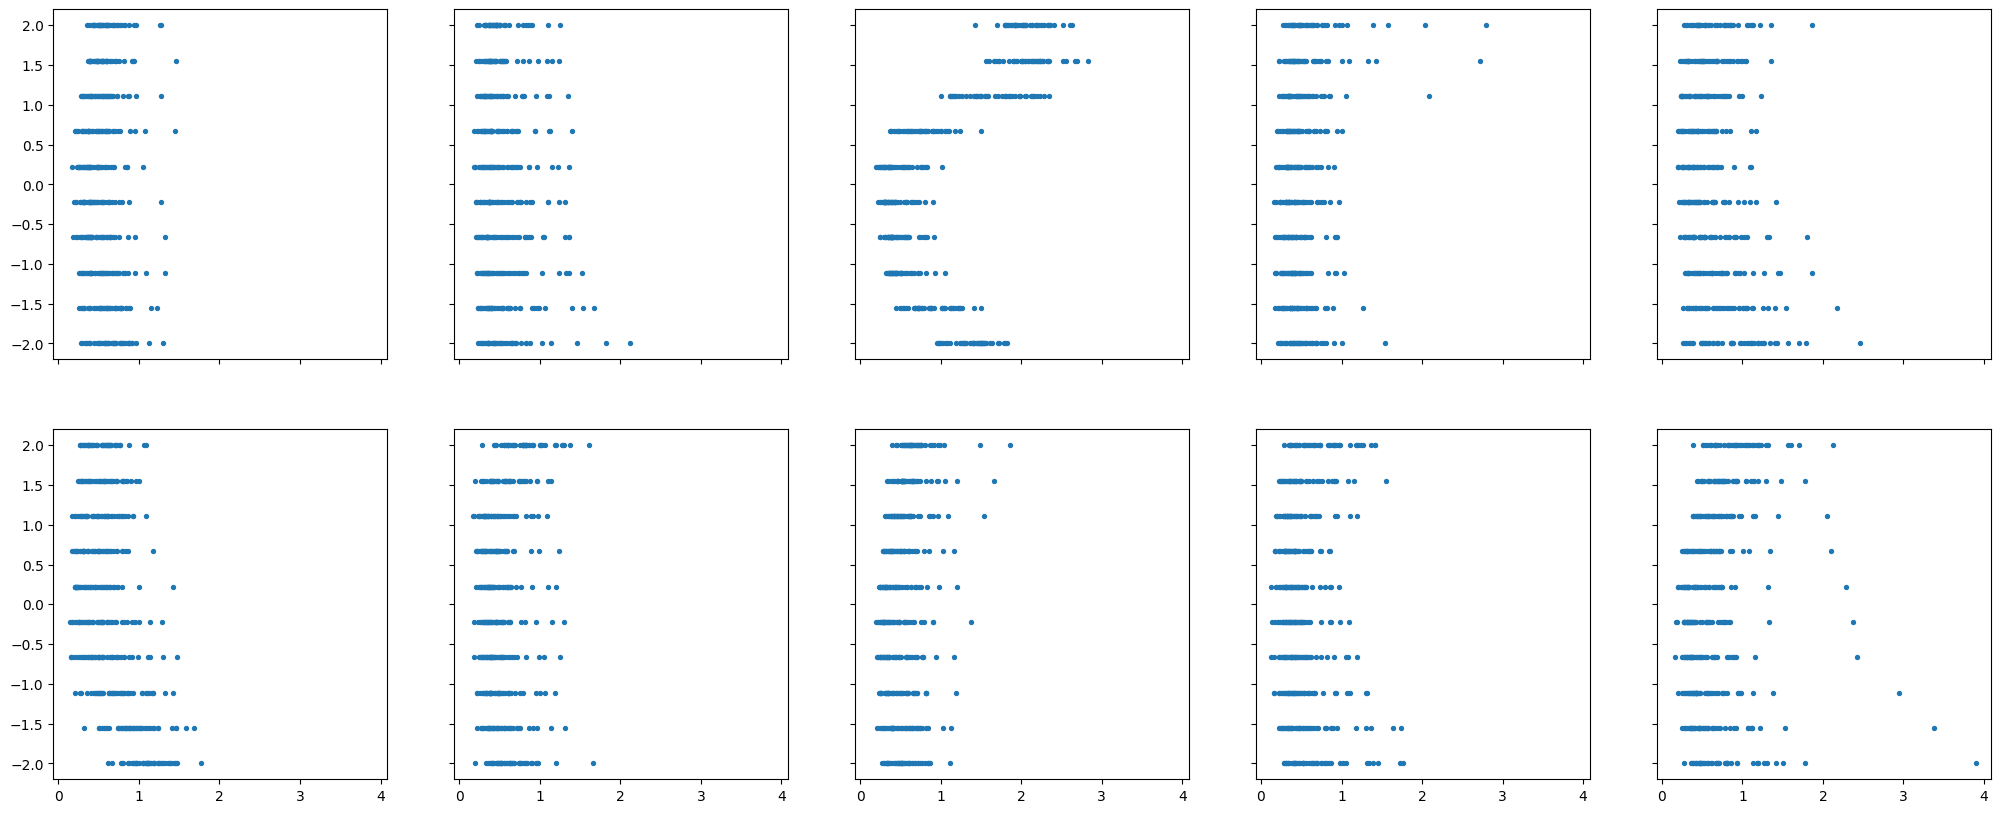

In [124]:
from sklearn.linear_model import LinearRegression

fig, axes = plt.subplots(2, 5, figsize=(25, 10), sharex=True, sharey=True)
axes = axes.flatten()


for slider_idx in range(10):

    D_pos = features[torch_slider_labels == slider_idx]
    D_neg = features[torch_slider_labels != slider_idx]

    y_cont_labels = torch_cont_labels[torch_slider_labels == slider_idx]

    D_pos_mean = D_pos.mean(dim=0)
    D_neg_mean = D_neg.mean(dim=0)

    cav = D_pos_mean - D_neg_mean

    distances = torch.sum((D_pos - D_neg_mean)**2, dim=1)

    # reg = LinearRegression().fit(distances.reshape(-1, 1), y_cont_labels)

    axes[slider_idx].scatter(distances, y_cont_labels, s=8)
    # axes[slider_idx].hist(distances, bins=20)

    # axes[slider_idx].plot([0, 4], [reg.intercept_, reg.coef_[0]*distances.max() + reg.intercept_])

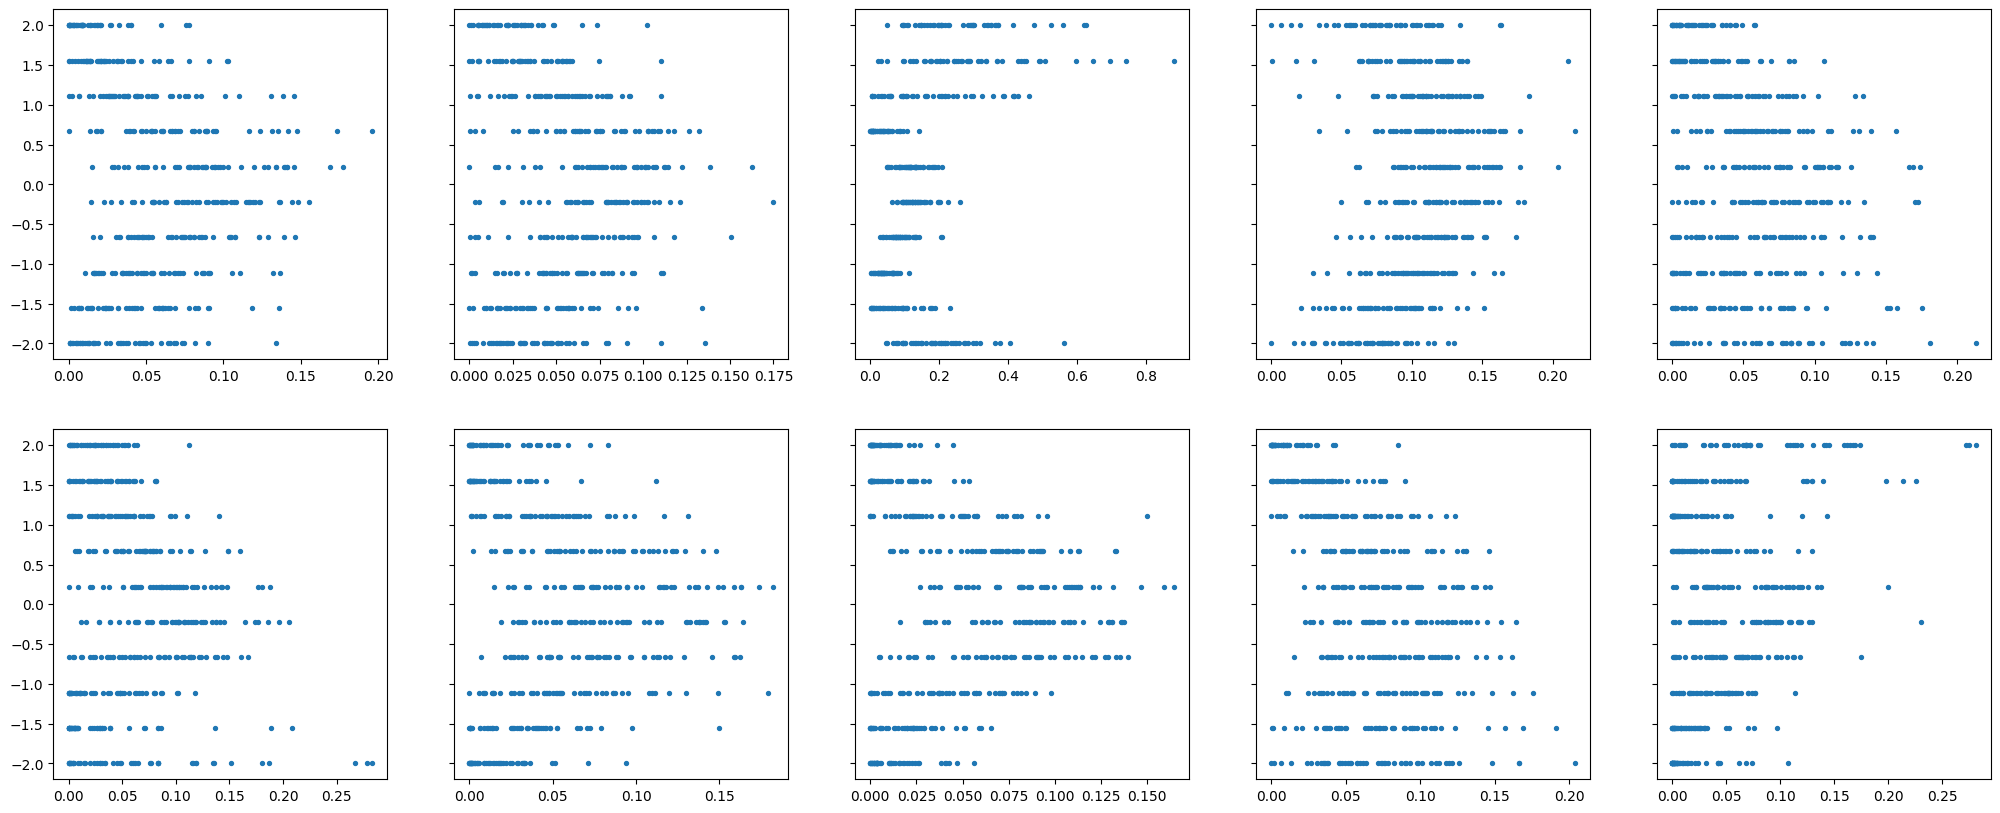

In [122]:
from sklearn.svm import SVC


fig, axes = plt.subplots(2, 5, figsize=(25, 10), sharex=False, sharey=True)
axes = axes.flatten()

for slider_idx in range(10):

    cav_labels = (torch_slider_labels == slider_idx)*1

    svm = SVC(kernel='linear').fit(features, cav_labels)

    D_pos = features[torch_slider_labels == slider_idx]
    y_cont_labels = torch_cont_labels[torch_slider_labels == slider_idx]

    d = abs(D_pos @ svm.coef_.T + svm.intercept_)**2 / np.linalg.norm(svm.coef_, ord=2)

    axes[slider_idx].scatter(d, y_cont_labels, s=8)

## CLIP test 2

In [89]:
def load_slider_images(images_path, slider_id, images, slider_labels, cont_labels):
    
    scales = np.linspace(-2, 2, 10)
    
    slider_path = os.path.join(images_path, os.listdir(images_path)[slider_id])
    file_names = os.listdir(slider_path)
    images.extend([Image.open(os.path.join(slider_path, f)) for f in file_names])
    cont_labels.extend([scales[int(f[-5])] for f in file_names])
    slider_labels.extend([slider_id for _ in file_names])

    return images, slider_labels, cont_labels

In [90]:
import os

base_face_path = r'C:\Users\janba\Downloads\face'
base_animal_path = r'C:\Users\janba\Downloads\animal'
base_plant_path = r'C:\Users\janba\Downloads\plant'

face_slider_id = 4
animal_slider_id = 1
plant_slider_id = 1

images = []
slider_labels = []
cont_labels = []

images, slider_labels, cont_labels = load_slider_images(base_face_path, face_slider_id, images, slider_labels, cont_labels)
images, slider_labels, cont_labels = load_slider_images(base_animal_path, animal_slider_id, images, slider_labels, cont_labels)
images, slider_labels, cont_labels = load_slider_images(base_plant_path, plant_slider_id, images, slider_labels, cont_labels)

In [91]:
batch = torch.stack([preprocess(im) for im in images]).to(device)

batch.shape

torch.Size([1490, 3, 224, 224])

In [92]:
torch.cuda.empty_cache()

In [93]:
from torch.utils.data import DataLoader

loader = DataLoader(batch, batch_size=32, shuffle=False)

len(loader)

47

In [94]:
batch_features = []

with torch.no_grad():
    for mini_batch in loader:

        batch_features.append(model.encode_image(mini_batch).cpu())
        torch.cuda.empty_cache()

In [95]:
features = torch.concatenate([torch.vstack(batch_features[:-1]), batch_features[-1]], dim=0)

features.shape

torch.Size([1490, 512])

In [96]:
torch_slider_labels = torch.tensor(slider_labels)
torch_cont_labels = torch.tensor(cont_labels)

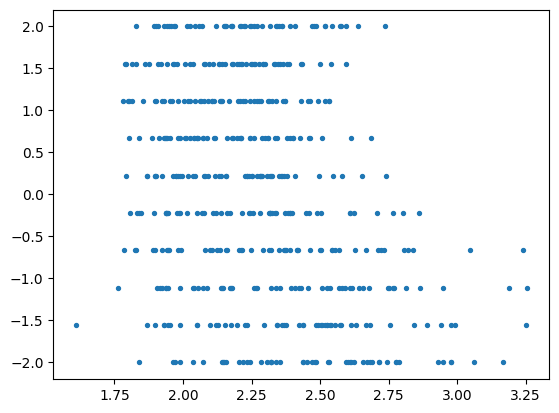

In [100]:
from sklearn.linear_model import LinearRegression

# fig, axes = plt.subplots(2, 5, figsize=(25, 10), sharex=False, sharey=True)
# axes = axes.flatten()


# for slider_idx in range(10):

D_pos = features[torch_slider_labels == face_slider_id]
D_neg = features[torch_slider_labels != face_slider_id]

y_cont_labels = torch_cont_labels[torch_slider_labels == face_slider_id]

D_pos_mean = D_pos.mean(dim=0)
D_neg_mean = D_neg.mean(dim=0)

cav = D_pos_mean - D_neg_mean

distances = torch.sum((D_pos - D_neg_mean)**2, dim=1)

# reg = LinearRegression().fit(distances.reshape(-1, 1), y_cont_labels)

plt.scatter(distances, y_cont_labels, s=8)
# plt.hist(distances, bins=50)
plt.show()

# axes[slider_idx].plot([0, 4], [reg.intercept_, reg.coef_[0]*distances.max() + reg.intercept_])